<a href="https://colab.research.google.com/github/Ousmane145/ojs/blob/main/Modele_MLT_Mon_Memoire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Paramètres de simulation
n_lignes = 1000
regions = {
    'Saint-Louis': {'climat': 'Sahelien', 'precip': (200, 400), 'temp': (25, 35), 'elevage': 'Elevee'},
    'Matam': {'climat': 'Sahelien', 'precip': (150, 350), 'temp': (28, 40), 'elevage': 'Tres_Elevee'},
    'Tambacounda': {'climat': 'Soudanien', 'precip': (500, 900), 'temp': (26, 38), 'elevage': 'Moyenne'},
    'Kolda': {'climat': 'Soudano-Guineen', 'precip': (800, 1200), 'temp': (24, 32), 'elevage': 'Moyenne'},
    'Louga': {'climat': 'Sahelien', 'precip': (250, 450), 'temp': (26, 36), 'elevage': 'Elevee'},
    'Ziguinchor': {'climat': 'Guineen', 'precip': (1000, 1600), 'temp': (24, 30), 'elevage': 'Faible'},
    'Kaolack': {'climat': 'Soudanien', 'precip': (600, 800), 'temp': (27, 36), 'elevage': 'Elevee'},
    'Fatick': {'climat': 'Soudanien', 'precip': (500, 750), 'temp': (26, 35), 'elevage': 'Moyenne'}
}

data = []
start_date = datetime(2024, 1, 1)

for i in range(1, n_lignes + 1):
    reg_name = random.choice(list(regions.keys()))
    reg_info = regions[reg_name]

    # Choix de la maladie et espèce selon la logique du mémoire
    if random.random() > 0.5:
        maladie = "PPCB"
        espece = "Bovin"
        base_ta = random.uniform(0.03, 0.08) # TA plus faible pour PPCB
        base_cfr = random.uniform(0.15, 0.30)
    else:
        maladie = "PPR"
        espece = random.choice(["Ovin", "Caprin"])
        base_ta = random.uniform(0.10, 0.20) # TA plus élevée pour PPR
        base_cfr = random.uniform(0.30, 0.50)

    pop_totale = random.randint(100, 1500)
    n_malades = int(pop_totale * base_ta * random.uniform(0.8, 1.2))
    n_morts = int(n_malades * base_cfr * random.uniform(0.8, 1.2))

    # Calculs finaux
    ta = round(n_malades / pop_totale, 4) if pop_totale > 0 else 0
    cfr = round(n_morts / n_malades, 4) if n_malades > 0 else 0

    row = {
        'ID_Foyer': i,
        'Date': (start_date + timedelta(days=random.randint(0, 730))).strftime('%Y-%m-%d'),
        'Region': reg_name,
        'Maladie': maladie,
        'Espece': espece,
        'Population_Totale': pop_totale,
        'N_Malades': n_malades,
        'N_Morts': n_morts,
        'Taux_Attaque_TA': ta,
        'Taux_Letalite_CFR': cfr,
        'Temp_Moy_C': round(random.uniform(reg_info['temp'][0], reg_info['temp'][1]), 1),
        'Precip_Annuelle_mm': random.randint(reg_info['precip'][0], reg_info['precip'][1]),
        'Densite_Elevage': reg_info['elevage']
    }
    data.append(row)

df = pd.DataFrame(data)

# Sauvegarde
df.to_csv('simulation_1000_lignes.csv', index=False)
print("Fichier 'simulation_1000_lignes.csv' généré avec succès !")

Fichier 'simulation_1000_lignes.csv' généré avec succès !


#**Le code pour le modele multi-taches de mon memoire**

Chargement des données depuis simulation_1000_lignes.csv...
Entraînement en cours...
Époque 025 | Perte: 0.008616
Époque 050 | Perte: 0.006714
Époque 075 | Perte: 0.006406
Époque 100 | Perte: 0.006105
Époque 125 | Perte: 0.005665
Époque 150 | Perte: 0.004857

 RÉSULTATS ET MÉTRIQUES 

--- Métriques pour TA (Taux d'Attaque) ---
Erreur Quadratique Moyenne (MSE) : 0.001155
Erreur Absolue Moyenne (MAE)     : 0.027383
Score R² (Coefficient de dét.)    : 0.6315

--- Métriques pour CFR (Létalité) ---
Erreur Quadratique Moyenne (MSE) : 0.004611
Erreur Absolue Moyenne (MAE)     : 0.054357
Score R² (Coefficient de dét.)    : 0.6936


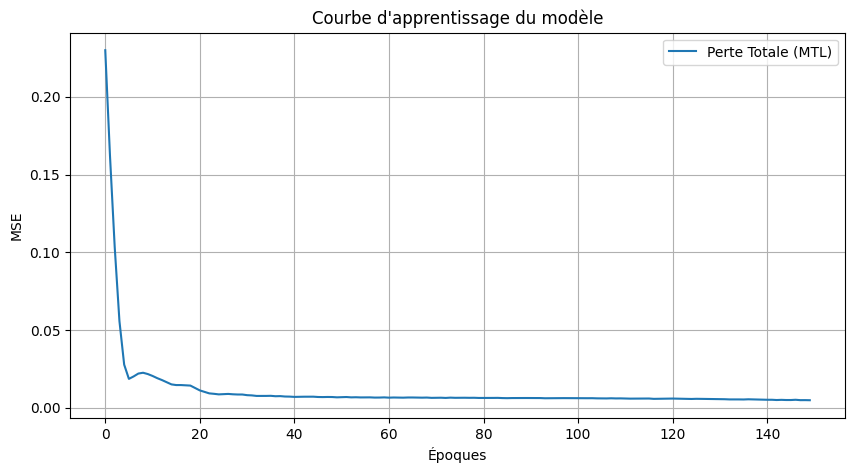

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. CONFIGURATION DU CHEMIN (Chemin par défaut dans Colab)
FILE_PATH = 'simulation_1000_lignes.csv'

# 2. PRÉTRAITEMENT DES DONNÉES
def load_and_preprocess(path):
    df = pd.read_csv(path)

    # Définition des variables
    features_cat = ['Region', 'Maladie', 'Espece', 'Densite_Elevage']
    features_num = ['Population_Totale', 'Temp_Moy_C', 'Precip_Annuelle_mm']
    targets = ['Taux_Attaque_TA', 'Taux_Letalite_CFR']

    # Pipeline de transformation
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
        ])

    X = preprocessor.fit_transform(df[features_cat + features_num])
    y = df[targets].values

    # Division Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test, X.shape[1]

# 3. ARCHITECTURE DU MODÈLE MTL
class MultiTaskNet(nn.Module):
    def __init__(self, input_size):
        super(MultiTaskNet, self).__init__()
        # Tronc commun
        self.shared = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        # Tête Taux d'Attaque (TA)
        self.head_ta = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        # Tête Létalité (CFR)
        self.head_cfr = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.shared(x)
        return self.head_ta(features), self.head_cfr(features)

# 4. EXÉCUTION ET MÉTRIQUES
def run_simulation():
    # Chargement
    print(f"Chargement des données depuis {FILE_PATH}...")
    X_train, X_test, y_train, y_test, input_dim = load_and_preprocess(FILE_PATH)

    # Conversion en tenseurs
    X_train_t = torch.FloatTensor(X_train)
    y_train_ta = torch.FloatTensor(y_train[:, 0]).view(-1, 1)
    y_train_cfr = torch.FloatTensor(y_train[:, 1]).view(-1, 1)

    X_test_t = torch.FloatTensor(X_test)

    # Initialisation
    model = MultiTaskNet(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    losses = []

    # Entraînement
    print("Entraînement en cours...")
    for epoch in range(150):
        model.train()
        optimizer.zero_grad()

        pred_ta, pred_cfr = model(X_train_t)

        loss_ta = criterion(pred_ta, y_train_ta)
        loss_cfr = criterion(pred_cfr, y_train_cfr)
        total_loss = loss_ta + loss_cfr

        total_loss.backward()
        optimizer.step()
        losses.append(total_loss.item())

        if (epoch+1) % 25 == 0:
            print(f"Époque {epoch+1:03d} | Perte: {total_loss.item():.6f}")

    # ÉVALUATION ET MÉTRIQUES
    model.eval()
    with torch.no_grad():
        test_pred_ta, test_pred_cfr = model(X_test_t)

        # Conversion en numpy pour calcul des métriques Sklearn
        p_ta, p_cfr = test_pred_ta.numpy(), test_pred_cfr.numpy()
        r_ta, r_cfr = y_test[:, 0].reshape(-1, 1), y_test[:, 1].reshape(-1, 1)

    print("\n" + "="*30)
    print(" RÉSULTATS ET MÉTRIQUES ")
    print("="*30)

    for name, pred, real in [("TA (Taux d'Attaque)", p_ta, r_ta), ("CFR (Létalité)", p_cfr, r_cfr)]:
        mse = mean_squared_error(real, pred)
        mae = mean_absolute_error(real, pred)
        r2 = r2_score(real, pred)
        print(f"\n--- Métriques pour {name} ---")
        print(f"Erreur Quadratique Moyenne (MSE) : {mse:.6f}")
        print(f"Erreur Absolue Moyenne (MAE)     : {mae:.6f}")
        print(f"Score R² (Coefficient de dét.)    : {r2:.4f}")

    # Visualisation de la courbe de perte
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Perte Totale (MTL)')
    plt.title('Courbe d\'apprentissage du modèle')
    plt.xlabel('Époques')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    run_simulation()
